# 06 · Dérive des données et dérive du modèle

**Question : comment savoir que le modèle doit être réentraîné ?**

- **dérive des données** (*data drift*) : la distribution des entrées change → PSI (Population Stability Index) et test de Kolmogorov-Smirnov ;
- **dérive du modèle** (*model drift*) : l'erreur du modèle augmente sur les données récentes → MAE hebdomadaire vs MAE du test.

Ces calculs sont ceux de `src/monitor.py`, lancé chaque semaine par GitHub Actions (`monitoring.yml`), qui déclenche un réentraînement en cas de dérive.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True, "grid.alpha": 0.3})

from scipy.stats import ks_2samp

from src.data import load_series
from src.monitor import psi

series = load_series().set_index("timestamp")["consommation_mw"]
series.index = series.index.tz_convert("Europe/Paris").tz_localize(None)
monthly = {period: values for period, values in series.groupby(series.index.to_period("M")) if len(values) > 1000}

## Choisir la bonne référence

La consommation est saisonnière : comparer août à janvier signalerait une « dérive » tous les ans. On calcule le PSI sur des fenêtres de 4 semaines (comme `src/monitor.py`) avec deux références :

- **naïve** : les 4 semaines précédentes ;
- **saisonnière** : les mêmes 4 semaines un an plus tôt.

In [2]:
window = pd.Timedelta(weeks=4)
rows = []
for start in pd.date_range("2014-01-01", series.index.max() - window, freq="4W"):
    current = series[(series.index > start) & (series.index <= start + window)]
    previous = series[(series.index > start - window) & (series.index <= start)]
    last_year = series[(series.index > start - pd.DateOffset(years=1)) & (series.index <= start + window - pd.DateOffset(years=1))]
    rows.append({"début": start, "vs 4 semaines précédentes": psi(previous, current), "vs mêmes semaines N-1": psi(last_year, current)})
drift = pd.DataFrame(rows).set_index("début")

print("Part des fenêtres au-dessus du seuil « classique » de 0.2 :")
(drift > 0.2).mean().round(2)

Part des fenêtres au-dessus du seuil « classique » de 0.2 :


vs 4 semaines précédentes    0.67
vs mêmes semaines N-1        0.39
dtype: float64

La référence saisonnière divise par deux les alertes. Mais même ainsi, le seuil « classique » de 0.2 (issu du scoring bancaire) se déclencherait sur plus d'une fenêtre sur trois : la météo varie beaucoup d'une année à l'autre. **On calibre donc le seuil sur l'historique** : le 90e percentile des PSI saisonniers, c'est-à-dire une alerte environ une fois sur dix.

Seuil calibré (90e percentile) : 1.45  → reporté dans params.yaml (monitoring.psi_threshold)


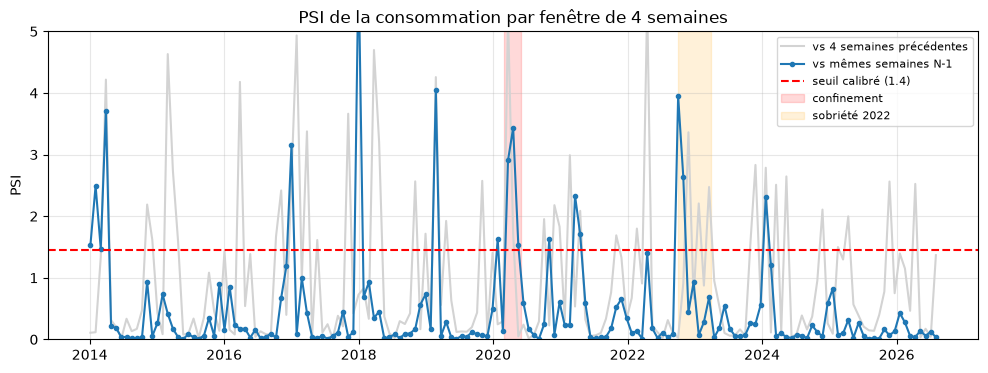

In [3]:
threshold = drift["vs mêmes semaines N-1"].quantile(0.9)
print(f"Seuil calibré (90e percentile) : {threshold:.2f}  → reporté dans params.yaml (monitoring.psi_threshold)")

fig, ax = plt.subplots()
ax.plot(drift.index, drift["vs 4 semaines précédentes"], color="lightgrey", label="vs 4 semaines précédentes")
ax.plot(drift.index, drift["vs mêmes semaines N-1"], marker=".", label="vs mêmes semaines N-1")
ax.axhline(threshold, color="red", linestyle="--", label=f"seuil calibré ({threshold:.1f})")
ax.axvspan(pd.Timestamp("2020-03-01"), pd.Timestamp("2020-05-31"), color="red", alpha=0.15, label="confinement")
ax.axvspan(pd.Timestamp("2022-10-01"), pd.Timestamp("2023-03-31"), color="orange", alpha=0.15, label="sobriété 2022")
ax.set(title="PSI de la consommation par fenêtre de 4 semaines", ylabel="PSI", ylim=(0, 5))
ax.legend(fontsize=8);

In [4]:
alerts = drift.loc[drift["vs mêmes semaines N-1"] > threshold, ["vs mêmes semaines N-1"]].sort_values("vs mêmes semaines N-1", ascending=False)
alerts.head(10)

,vs mêmes semaines N-1
début,
2017-12-31,6.093222
2019-02-24,4.044064
2022-10-02,3.953905
2014-03-30,3.714642
2020-04-19,3.433349
2017-01-01,3.162939
2020-03-22,2.906881
2022-10-30,2.637313
2014-02-02,2.493609


**Lecture :** au-dessus du seuil calibré, on ne trouve que de vrais événements : les vagues de froid (janvier 2017, février 2018 — détectées aussi l'année suivante, quand elles servent de référence), le confinement de 2020 et la crise énergétique de 2022.

Une alerte de dérive des données ne signifie pas que le modèle se trompe : les lags s'adaptent souvent. D'où la seconde surveillance, sur l'erreur du modèle. Un réentraînement déclenché inutilement n'est pas dangereux : la **promotion champion / challenger** ne remplace la production que si le nouveau modèle fait mieux.

## Situation actuelle

PSI : 0.046  (seuil 1.4)
KS p-value : 0.0119


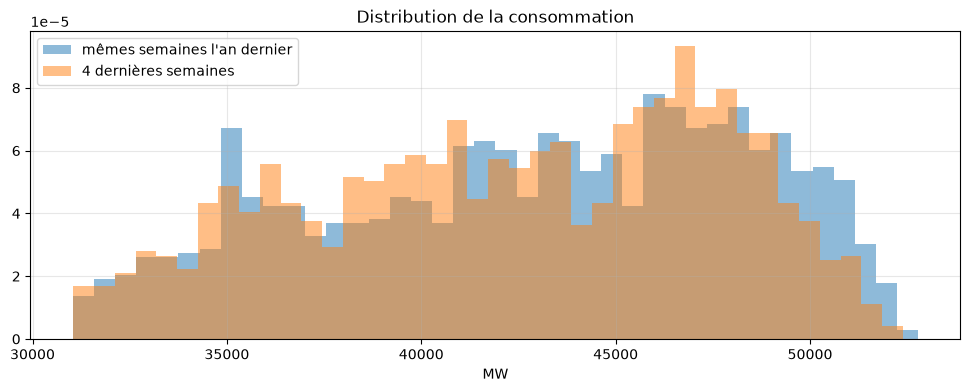

In [5]:
end = series.index.max()
current = series[series.index > end - pd.Timedelta(weeks=4)]
reference = series[(series.index > end - pd.Timedelta(weeks=4) - pd.DateOffset(years=1)) & (series.index <= end - pd.DateOffset(years=1))]

print(f"PSI : {psi(reference, current):.3f}  (seuil {threshold:.1f})")
print(f"KS p-value : {ks_2samp(reference, current).pvalue:.3g}")
fig, ax = plt.subplots()
ax.hist(reference, bins=40, alpha=0.5, density=True, label="mêmes semaines l'an dernier")
ax.hist(current, bins=40, alpha=0.5, density=True, label="4 dernières semaines")
ax.set(title="Distribution de la consommation", xlabel="MW")
ax.legend();

**PSI vs KS :** avec des milliers de points, le test KS devient significatif pour des écarts minimes (p-value faible même sans changement métier). Le PSI mesure l'**ampleur** du changement : c'est lui qui sert de seuil d'alerte, le KS reste une information complémentaire.

## Dérive du modèle

La dérive des données ne dit pas si le modèle se trompe davantage. `src/monitor.py` suit donc aussi la **MAE hebdomadaire** du modèle `@production` sur les données RTE récentes, comparée à sa MAE de test (+20 % = alerte). Les résultats de chaque contrôle sont enregistrés dans MLflow (runs `stage=monitoring`) et affichés dans l'onglet *Monitoring drift* de l'application.

In [6]:
import mlflow

from src.config import configure_mlflow

configure_mlflow()
monitorings = mlflow.search_runs(filter_string="tags.stage = 'monitoring'", order_by=["attributes.start_time DESC"])
monitorings[["start_time", "tags.window", "tags.model_version", "metrics.psi", "metrics.mae_last_week", "metrics.mae_reference", "metrics.data_drift", "metrics.model_drift"]].head()

,start_time,tags.window,tags.model_version,metrics.psi,metrics.mae_last_week,metrics.mae_reference,metrics.data_drift,metrics.model_drift
0,2026-09-23 21:32:16.243000+00:00,2026-08-26 → 2026-09-23,1,0.045201,967.570969,1161.385411,0.0,0.0
